# **DL Lab 8**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**


In [13]:
import numpy as np
import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Resizing, Dropout, GlobalAveragePooling2D
from keras.applications import VGG16, ResNet50
from keras.optimizers import SGD, Adam, RMSprop
from keras.utils import to_categorical
import keras_tuner as kt
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import tensorflow as tf

# **Question 1**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


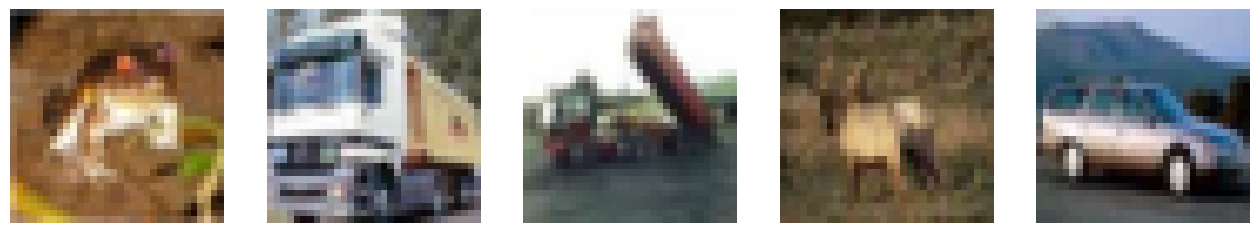

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
fig, axs = plt.subplots(1, 5, figsize=(16, 4))
for i in range(5):
    axs[i].imshow(X_train[i])
    axs[i].axis('off')    
plt.show()

In [3]:
print(f"Shape of X_train: {X_train.shape} and X_test: {X_test.shape}")

Shape of X_train: (50000, 32, 32, 3) and X_test: (10000, 32, 32, 3)


In [4]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train/255
X_test = X_test/255

In [5]:
model1 = Sequential()
model1.add(Conv2D(30, 5, strides=[1,1], activation='relu', padding='valid', input_shape=(32,32, 3)))
model1.add(MaxPool2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model1.add(Conv2D(20, 5, strides=(1, 1), activation="relu", padding='valid'))
model1.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model1.add(Conv2D(10, 3, strides=(1, 1), activation="relu", padding='valid'))
model1.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model1.add(Flatten())
model1.add(Dense(100, activation='relu'))
model1.add(Dense(100, activation='softmax'))
model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1758364438.004442      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 30)     │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 20)     │        15,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 10)       │         1,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        36,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,310 (255.12 KB)

 Trainable params: 65,310 (255.12 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
estop = EarlyStopping(monitor = 'val_loss', min_delta = 1e-4, mode= 'min', patience=4, verbose = 1, restore_best_weights=True)

In [7]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
hist1 = model1.fit(X_train, y_train, batch_size=56, epochs=20, verbose=1, validation_data=(X_test, y_test), callbacks=[estop])

Epoch 1/20


I0000 00:00:1758364470.546494      97 service.cc:148] XLA service 0x7b82d80062e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758364470.547269      97 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1758364470.835321      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


 53/893 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1107 - loss: 3.1867

I0000 00:00:1758364472.874880      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


893/893 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2436 - loss: 2.1343 - val_accuracy: 0.4198 - val_loss: 1.5613
Epoch 2/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4443 - loss: 1.5237 - val_accuracy: 0.4852 - val_loss: 1.4114
Epoch 3/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5002 - loss: 1.3841 - val_accuracy: 0.5399 - val_loss: 1.2754
Epoch 4/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5363 - loss: 1.2903 - val_accuracy: 0.5297 - val_loss: 1.3148
Epoch 5/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5613 - loss: 1.2186 - val_accuracy: 0.5613 - val_loss: 1.2094
Epoch 6/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5837 - loss: 1.1648 - val_accuracy: 0.5958 - val_loss: 1.1312
Epoch 7/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5998 - loss: 1.1168 - val_accuracy: 0.5621 - val_loss: 1.2128
Epoch 8/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6135 - loss: 1.0864 - val_accuracy: 0.5887 - val

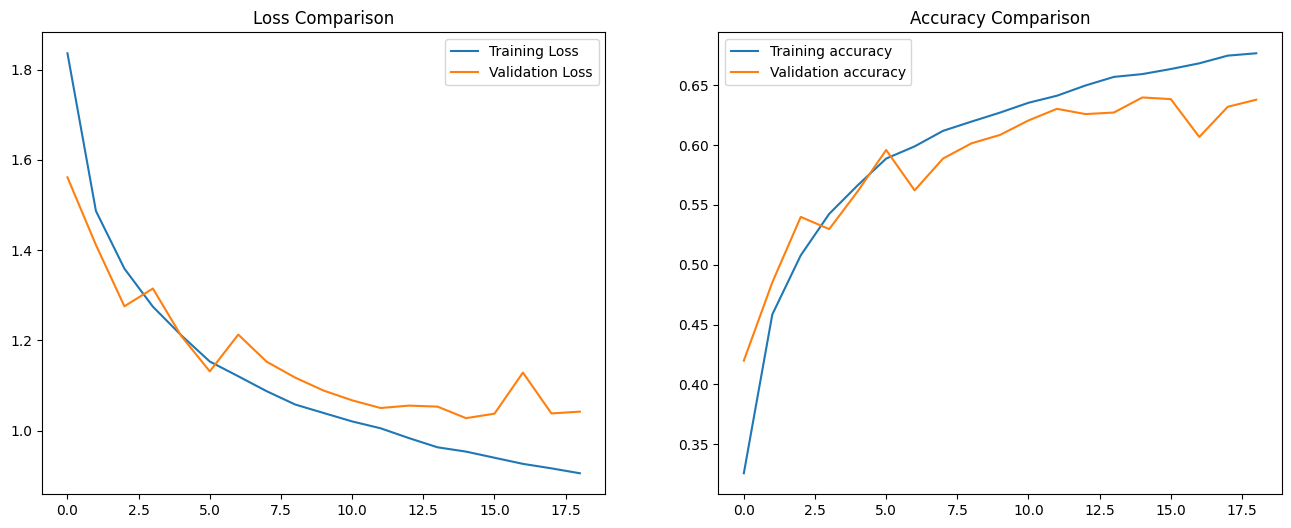

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist1.history['loss'], label='Training Loss')
axs[0].plot(hist1.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist1.history['accuracy'], label='Training accuracy')
axs[1].plot(hist1.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

# **Question 2**

In [9]:
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
model2 = Sequential()
model2.add(Resizing(224, 224, input_shape=(32,32,3)))
model2.add(base_model)
model2.add(GlobalAveragePooling2D())
model2.add(Flatten())
model2.add(Dense(100, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(50, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(10, activation='softmax'))

model2.summary()
model2.compile(loss="sparse_categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,771,548 (56.35 MB)

 Trainable params: 56,860 (222.11 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
hist2 = model2.fit(X_train, y_train, batch_size=56, epochs=20, verbose=1, validation_data=(X_test, y_test), callbacks=[estop])

Epoch 1/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 151s 152ms/step - accuracy: 0.2089 - loss: 2.0964 - val_accuracy: 0.4442 - val_loss: 1.5529
Epoch 2/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - accuracy: 0.3865 - loss: 1.6525 - val_accuracy: 0.5195 - val_loss: 1.3890
Epoch 3/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - accuracy: 0.4351 - loss: 1.5435 - val_accuracy: 0.5478 - val_loss: 1.3048
Epoch 4/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - accuracy: 0.4663 - loss: 1.4751 - val_accuracy: 0.5580 - val_loss: 1.2465
Epoch 5/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - accuracy: 0.4836 - loss: 1.4306 - val_accuracy: 0.5641 - val_loss: 1.2329
Epoch 6/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - accuracy: 0.4956 - loss: 1.3989 - val_accuracy: 0.5635 - val_loss: 1.2264
Epoch 7/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - accuracy: 0.5075 - loss: 1.3777 - val_accuracy: 0.5730 - val_loss: 1.2122
Epoch 8/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 116s 130ms/step - accuracy: 0.5149 -

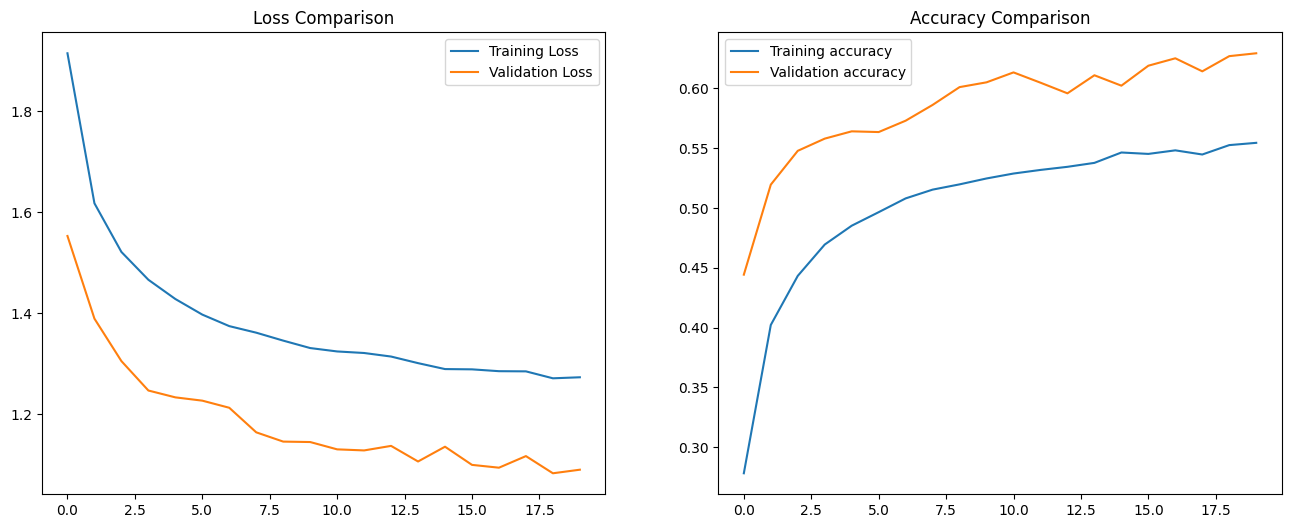

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist2.history['loss'], label='Training Loss')
axs[0].plot(hist2.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist2.history['accuracy'], label='Training accuracy')
axs[1].plot(hist2.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

# **Question 3**

In [19]:
resnet_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in resnet_model.layers:
    layer.trainable = False

In [22]:
from tensorflow import keras
from tensorflow.keras import layers

In [24]:
model3 = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Resizing(224, 224),
    layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    resnet_model,
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(50, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(10, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_4 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,798,172 (90.78 MB)

 Trainable params: 210,460 (822.11 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [25]:
hist3 = model3.fit(X_train, y_train, batch_size=64, epochs=10, verbose=1, validation_data=(X_test, y_test), callbacks=[estop])

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 100ms/step - accuracy: 0.1015 - loss: 2.3157 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.0972 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.0988 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.1005 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.0959 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


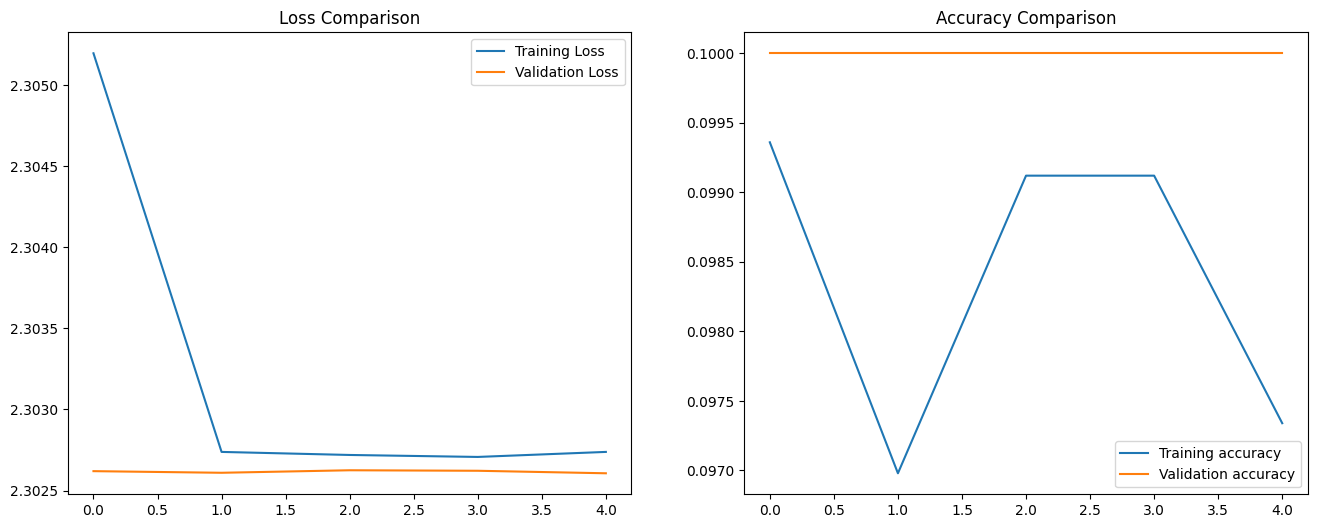

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist3.history['loss'], label='Training Loss')
axs[0].plot(hist3.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist3.history['accuracy'], label='Training accuracy')
axs[1].plot(hist3.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()